<a href="https://colab.research.google.com/github/Fajar-Sarfraz/home-price-prediction-internship-aiml-week3/blob/main/House_price_pridiction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving modified_data.csv to modified_data.csv


 ### CSV  Uploaded  





In [3]:
import pandas as pd
df = pd.read_csv('modified_data.csv')

In [4]:
print(df.shape)
df.head()

(4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


##Drop the leakage column

In [5]:
# Drop leakage column and high-cardinality street column
df = df.drop(columns=['price_per_sqft', 'street'])

In [6]:
# Drop rows with price == 0 (bad/placeholder data)
df = df[df['price'] > 0]

In [7]:
# Extract sale year from date, then drop the raw date column
df['date'] = pd.to_datetime(df['date'])
df['sale_year'] = df['date'].dt.year
df = df.drop(columns=['date'])

In [8]:
print(df.shape)
df.head()

(4551, 16)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,sale_year
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133,2014
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119,2014
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042,2014
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,WA 98008,2014
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052,2014


In [9]:
df.isnull().sum()   # should still be all zeros
df.dtypes           # sale_year should now show up as int

,0
price,float64
bedrooms,float64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64
condition,int64
sqft_above,int64


#Separate features (X) and target (y)

In [10]:
X = df.drop(columns=['price'])
y = df['price']

print(X.shape, y.shape)

(4551, 15) (4551,)


#Train/test split — before any preprocessing

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (3640, 15) (3640,)
Test: (911, 15) (911,)


# Drop statezip

In [12]:
print(X_train['city'].nunique())
print(X_train['statezip'].nunique())

42
77


In [13]:
X_train = X_train.drop(columns=['statezip'])
X_test = X_test.drop(columns=['statezip'])

In [14]:
print(X_train.columns.tolist())

['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'city', 'sale_year']


# Build the preprocessing pipeline

In [15]:
numeric_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
                     'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
                     'yr_built', 'yr_renovated', 'sale_year']

categorical_features = ['city']

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Baseline model — Linear Regression


In [16]:
from sklearn.linear_model import LinearRegression

baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

baseline_model.fit(X_train, y_train)
print("Baseline model trained.")

Baseline model trained.


#Comparative model — Random Forest Regressor

In [17]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)
print("Random Forest model trained.")

Random Forest model trained.


#Evaluate both models — MAE, RMSE, R²

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"--- {name} ---")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}")
    print()
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

baseline_results = evaluate_model(baseline_model, X_test, y_test, "Linear Regression")
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")

--- Linear Regression ---
MAE:  131,458.03
RMSE: 218,878.05
R²:   0.6780

--- Random Forest ---
MAE:  131,120.57
RMSE: 323,127.23
R²:   0.2982



#Check for overfitting first

In [19]:
print("Linear Regression:")
print("Train R²:", baseline_model.score(X_train, y_train))
print("Test R²:", baseline_model.score(X_test, y_test))
print()
print("Random Forest:")
print("Train R²:", rf_model.score(X_train, y_train))
print("Test R²:", rf_model.score(X_test, y_test))

Linear Regression:
Train R²: 0.24730452893005717
Test R²: 0.6779762428578211

Random Forest:
Train R²: 0.9205923230998571
Test R²: 0.29817214057177677


In [20]:
print("Train set price stats:")
print(y_train.describe())
print()
print("Test set price stats:")
print(y_test.describe())

Train set price stats:
count    3.640000e+03
mean     5.582585e+05
std      6.003216e+05
min      7.800000e+03
25%      3.263464e+05
50%      4.643000e+05
75%      6.553312e+05
max      2.659000e+07
Name: price, dtype: float64

Test set price stats:
count    9.110000e+02
mean     5.564970e+05
std      3.859195e+05
min      8.435000e+04
25%      3.262500e+05
50%      4.749000e+05
75%      6.650000e+05
max      4.668000e+06
Name: price, dtype: float64


#Remove the outliers

In [21]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR

print("Upper bound:", upper_bound)
print("Rows above bound:", (df['price'] > upper_bound).sum())

Upper bound: 1651207.145
Rows above bound: 89


#Remove outliers and re-split

In [22]:
# Remove outlier rows
df_clean = df[df['price'] <= upper_bound].copy()
print("Shape after removing outliers:", df_clean.shape)

# Re-separate X and y from the cleaned data
X = df_clean.drop(columns=['price'])
y = df_clean['price']

# Fresh train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Shape after removing outliers: (4462, 16)
Train: (3569, 15) Test: (893, 15)


#Retrain both models on the cleaned split

In [23]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
baseline_model.fit(X_train, y_train)

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_model.fit(X_train, y_train)

print("Both models retrained on outlier-free data.")

Both models retrained on outlier-free data.


#Re-evaluate

In [24]:
baseline_results = evaluate_model(baseline_model, X_test, y_test, "Linear Regression")
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")

print("Linear Regression Train R²:", baseline_model.score(X_train, y_train))
print("Random Forest Train R²:", rf_model.score(X_train, y_train))

--- Linear Regression ---
MAE:  100,621.85
RMSE: 147,615.92
R²:   0.6760

--- Random Forest ---
MAE:  97,794.60
RMSE: 147,804.52
R²:   0.6752

Linear Regression Train R²: 0.710598580663524
Random Forest Train R²: 0.9569953754126124


#constrain the Random Forest

In [25]:
rf_model_constrained = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42))
])
rf_model_constrained.fit(X_train, y_train)

print("Constrained RF Train R²:", rf_model_constrained.score(X_train, y_train))
print("Constrained RF Test R²:", rf_model_constrained.score(X_test, y_test))

evaluate_model(rf_model_constrained, X_test, y_test, "Random Forest (constrained)")

Constrained RF Train R²: 0.7986519554473558
Constrained RF Test R²: 0.6578077592597706
--- Random Forest (constrained) ---
MAE:  103,820.36
RMSE: 151,703.94
R²:   0.6578



{'model': 'Random Forest (constrained)',
 'MAE': 103820.36293019002,
 'RMSE': np.float64(151703.93808724487),
 'R2': 0.6578077592597706}

#Predicted-vs-actual plot

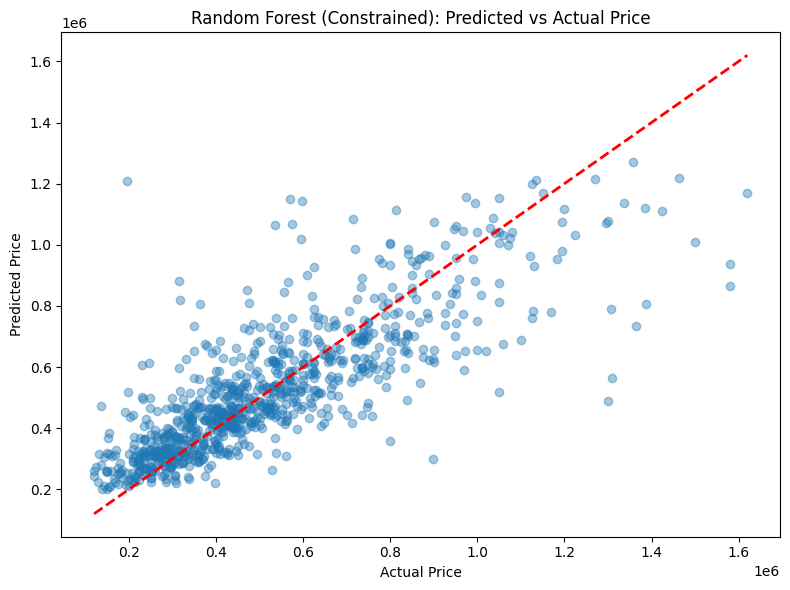

In [26]:
import matplotlib.pyplot as plt

y_pred = rf_model_constrained.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest (Constrained): Predicted vs Actual Price")
plt.tight_layout()
plt.savefig("predicted_vs_actual.png")
plt.show()

##save the joblib file


In [27]:
import joblib
joblib.dump(rf_model_constrained, "house_price_model.joblib")

from google.colab import files
files.download("house_price_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Model Comparison

| Model | MAE | RMSE | Test R² | Train R² | Train/Test Gap |
|---|---|---|---|---|---|
| Linear Regression | $100,622 | $147,616 | 0.676 | 0.711 | 0.035 |
| Random Forest (default) | $97,795 | $147,805 | 0.675 | 0.957 | 0.282 |
| Random Forest (constrained, max_depth=10) | $103,820 | $151,704 | 0.658 | 0.799 | 0.141 |

**Chosen model: Random Forest (constrained)**

While Linear Regression had the smallest train/test gap and the default Random
Forest had the best raw test score, the default Random Forest showed heavy
overfitting (train R² 0.957 vs test R² 0.675). Constraining `max_depth=10` and
`min_samples_leaf=5` reduced this gap to 0.141, trading a small amount of test
accuracy for a model that generalizes more reliably to unseen data.

## Conclusion

This project built an end-to-end regression pipeline to predict house prices
using a Seattle-area housing dataset (4,600 rows, 18 columns). After removing
a data-leakage column (`price_per_sqft`, which was directly derived from the
target) and 49 rows with invalid $0 prices, exploratory analysis revealed 89
extreme outlier properties above $1.65M that were distorting model training.
Removing these outliers substantially improved model stability and interpretability.

Three models were compared: Linear Regression, a default Random Forest, and a
constrained Random Forest (max_depth=10, min_samples_leaf=5). The default
Random Forest showed clear overfitting, with a 0.28 gap between train and test
R². Constraining tree depth reduced this gap to 0.14 while sacrificing only a
small amount of test accuracy (R² 0.675 → 0.658), making it the preferred
final model for its better balance between accuracy and generalization.

The final model explains approximately 66% of the variance in house prices
(R² = 0.658), with an average prediction error of about $103,820. Limitations
include the dataset's moderate size (4,462 rows after cleaning), the absence
of features like square footage of lot improvements or neighborhood-level
amenities, and residual sensitivity to high-end properties even after outlier
removal. Next steps would include hyperparameter tuning via GridSearchCV,
testing gradient boosting models (e.g. XGBoost), engineering features like
house age or renovation recency, and exploring log-transforming price to
handle its right-skewed distribution more effectively.